In [1]:
#Starting with using Statsmodels

In [2]:
import pandas as pd
import numpy as np

In [5]:
ebay = pd.read_csv("/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/codes/Data/eBayClean.csv")

In [7]:
train = ebay.sample(frac=0.7, random_state=1031)
test = ebay.drop(labels = train.index)

In [8]:
train.columns

Index(['UniqueID', 'sold', 'biddable', 'startprice', 'condition', 'cellular',
       'carrier', 'color', 'storage', 'productline', 'noDescription',
       'charCountDescription', 'upperCaseDescription', 'startprice_99end'],
      dtype='object')

In [9]:
train.dtypes

UniqueID                  int64
sold                      int64
biddable                 object
startprice              float64
condition                object
cellular                 object
carrier                  object
color                    object
storage                  object
productline              object
noDescription            object
charCountDescription      int64
upperCaseDescription      int64
startprice_99end         object
dtype: object

In [15]:
from statsmodels.formula.api import logit
logreg = logit('sold~startprice',  data = train)
model = logreg.fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.568922
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   sold   No. Observations:                 1303
Model:                          Logit   Df Residuals:                     1301
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Oct 2025   Pseudo R-squ.:                  0.1770
Time:                        09:47:33   Log-Likelihood:                -741.30
converged:                       True   LL-Null:                       -900.77
Covariance Type:            nonrobust   LLR p-value:                 2.466e-71
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.3148      0.109     12.094      0.000       1.102       1.528
startprice    -0.0076      0.001    -14.831      0.000      -0.009      -0.007
==============================================================================
"""

In [20]:
print('ln(p/1-p) =', model.params.iloc[0], '+', model.params.iloc[1], 'startprice')

ln(p/1-p) = 1.3147519151309588 + -0.007560240190138986 startprice


In [24]:
startprice_200 = pd.DataFrame({'startprice': [200]})
startprice_200
model.predict(startprice_200)

0    0.450835
dtype: float64

In [33]:
startprices = pd.DataFrame({'startprice': [-100, 0, 100, 200, 300, 1_000_000]})
startprices
(model.predict(startprices) > 0.4).astype('int')
model.predict(startprices)

/opt/anaconda3/envs/pred_env/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/envs/pred_env/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


0    0.888030
1    0.788307
2    0.636158
3    0.450835
4    0.278218
5    0.000000
dtype: float64

In [36]:
(
    train.loc[:, ['startprice', 'sold']]
    .assign(pred = model.predict())
    .assign(pred_binary = (model.predict() > 0.4).astype('int'))
)

,startprice,sold,pred,pred_binary
1107,196.0,0,0.458333,1
1833,529.0,0,0.063887,0
1351,425.0,0,0.130295,0
1576,315.0,0,0.256027,0
1170,275.0,0,0.317710,0
...,...,...,...,...
1509,235.0,0,0.386534,0
1020,500.0,0,0.078322,0
807,65.0,1,0.694944,1
1045,92.0,0,0.650039,1


In [41]:
np.exp(model.params.iloc[1])
#this is used to flip the intercept that is in log in the model to regular one -this is for the specific one in the equation as startptice

np.float64(0.9924682665412445)

In [42]:
np.exp(np.log(69))

np.float64(69.00000000000001)

In [44]:
(np.exp(model.params.iloc[1]) - 1) * 100
#you can also subsititute np to math.exp same thing 

np.float64(-0.7531733458755463)

In [47]:
train.select_dtypes('object').columns
# this will sort the categorical or string variables from the data

Index(['biddable', 'condition', 'cellular', 'carrier', 'color', 'storage',
       'productline', 'noDescription', 'startprice_99end'],
      dtype='object')

In [48]:
train.color.value_counts()

color
Unknown       496
White         305
Black         305
Space Gray    143
Gold           54
Name: count, dtype: int64

In [49]:
logreg = logit('sold~color',  data = train)
model1 = logreg.fit()
model1.summary()

Optimization terminated successfully.
         Current function value: 0.686962
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   sold   No. Observations:                 1303
Model:                          Logit   Df Residuals:                     1298
Method:                           MLE   Df Model:                            4
Date:                Thu, 30 Oct 2025   Pseudo R-squ.:                0.006286
Time:                        10:21:56   Log-Likelihood:                -895.11
converged:                       True   LL-Null:                       -900.77
Covariance Type:            nonrobust   LLR p-value:                   0.02314
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.0984      0.115      0.859      0.391      -0.126       0.323
color[T.Gold]          -0.9634      0.319     -3.017      0.003      -1.589      -0.338
color[T.Space Gray]    -0.3373      0.204     -1.656      0.098      -0.737       0.062
color[T.Unknown]       -0.2034      0.146     -1.396      0.163      -0.489       0.082
color[T.White]         -0.2892      0.162     -1.780      0.075      -0.608       0.029
=======================================================================================
"""

In [51]:
(np.exp(model1.params.iloc[1]) - 1) * 100
#this just means that gold has statistically less probabilistic by 61%

np.float64(-61.84210526315789)

In [52]:
logreg = logit(formula='sold ~ biddable + startprice + condition + cellular + \
color + storage + productline + noDescription + upperCaseDescription + startprice_99end', data = train,)
model2 = logreg.fit()
model2.summary()

Optimization terminated successfully.
         Current function value: 0.454808
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   sold   No. Observations:                 1303
Model:                          Logit   Df Residuals:                     1277
Method:                           MLE   Df Model:                           25
Date:                Thu, 30 Oct 2025   Pseudo R-squ.:                  0.3421
Time:                        10:33:48   Log-Likelihood:                -592.61
converged:                       True   LL-Null:                       -900.77
Covariance Type:            nonrobust   LLR p-value:                4.666e-114
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               2.2508      0.672      3.349      0.001       0.934       3.568
biddable[T.not biddable]               -1.7329      0.159    -10.875      0.000      -2.045      -1.421
condition[T.new]                        1.3171      0.340      3.877      0.000       0.651       1.983
condition[T.refurbished]                0.7866      0.352      2.234      0.026       0.096       1.477
condition[T.used]                       0.8028      0.248      3.232      0.001       0.316       1.290
cellular[T.No cellular]                -0.2101      0.177     -1.188      0.235      -0.557       0.137
cellular[T.Unknown]                    -1.1743      0.400     -2.936      0.003      -1.958      -0.390
color[T.Gold]                           0.1844      0.512      0.360      0.719      -0.819       1.188
color[T.Space Gray]                     0.0740      0.298      0.248      0.804      -0.510       0.658
color[T.Unknown]                        0.0100      0.202      0.049      0.961      -0.386       0.406
color[T.White]                          0.0698      0.223      0.313      0.754      -0.367       0.506
storage[T.Less than 128 GB]            -0.8148      0.497     -1.638      0.101      -1.790       0.160
storage[T.Unknown]                     -0.0401      0.625     -0.064      0.949      -1.265       1.185
productline[T.iPad 1]                   0.1763      0.369      0.478      0.633      -0.547       0.899
productline[T.iPad 2]                   0.2199      0.359      0.612      0.541      -0.485       0.924
productline[T.iPad 3]                   0.7900      0.408      1.936      0.053      -0.010       1.590
productline[T.iPad 4]                   0.7948      0.410      1.938      0.053      -0.009       1.599
productline[T.iPad Air 1/2]             2.0521      0.421      4.880      0.000       1.228       2.876
productline[T.iPad mini]                0.4991      0.359      1.388      0.165      -0.205       1.204
productline[T.iPad mini 2]              1.5234      0.466      3.268      0.001       0.610       2.437
productline[T.iPad mini Retina]         2.4407      0.860      2.838      0.005       0.755       4.126
productline[T.iPad mini3]               1.1562      0.531      2.179      0.029       0.116       2.196
noDescription[T.no description]         0.0784      0.168      0.467      0.640      -0.250       0.407
startprice_99end[T.not a 99 ending]    -0.1012      0.161     -0.629      0.529      -0.416       0.214
startprice                             -0.0101      0.001    -10.276      0.000      -0.012      -0.008
upperCaseDescription                   -0.0128      0.009     -1.386      0.166      -0.031       0.005
=======================================================================================================
"""

In [53]:
# it will not be right to say that this model explains 34.21% variability in the data in this particular scenario
#log likelihood 
#

In [56]:
model.aic, model2.aic
#it is another metric
#AIC Akaike Information Criteria
#lower is better so model 2 is better

(np.float64(1486.609809125202), np.float64(1237.228656774646))

In [ ]:
#not biddable are not pref and not liked coz fo the coefficients 
# people like new, refurb, used over for parts
#

In [57]:
## We will start using scikitlearn

In [59]:
y = ebay.sold
X = ebay.drop(['UniqueID','sold'], axis = 1)
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, 
                                                            random_state=1031, 
                                                            train_size=0.7, 
                                                            stratify=y)

In [60]:
#categorical_features = ['biddable','condition','cellular', 'carrier', 'color','storage','productline','noDescription','startprice_99end']
categorical_features = X_train_raw.select_dtypes('object').columns

X_train = pd.get_dummies(X_train_raw, 
                         prefix_sep = '_', 
                         columns = categorical_features, 
                         drop_first = True)

X_test = pd.get_dummies(X_test_raw, 
                         prefix_sep = '_', 
                         columns = categorical_features, 
                         drop_first = True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_train.head()

,startprice,charCountDescription,upperCaseDescription,biddable_not biddable,condition_new,condition_refurbished,condition_used,cellular_No cellular,cellular_Unknown,carrier_Sprint/T-Mobile,...,productline_iPad 2,productline_iPad 3,productline_iPad 4,productline_iPad Air 1/2,productline_iPad mini,productline_iPad mini 2,productline_iPad mini Retina,productline_iPad mini3,noDescription_no description,startprice_99end_not a 99 ending
1510,160.00,0,0,True,False,False,True,True,False,False,...,False,False,False,False,True,False,False,False,True,True
576,279.00,99,1,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1468,100.00,99,58,False,False,False,True,True,False,False,...,False,False,False,False,True,False,False,False,False,True
950,829.99,0,0,True,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
435,500.00,95,5,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,False,True


In [61]:
from sklearn.linear_model import LogisticRegression
logit = LogisticRegression(max_iter=10000, random_state=1031)
logit.fit(X_train.loc[:,['startprice']], y_train)
#max iter 10000 means it will run a max no of interations capped at 10000 default 1000 too low

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1031
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [65]:
y_pred_proba = logit.predict_proba(X_train.loc[:,['startprice']])
y_pred_proba[:10,1] > 0.5

array([ True, False,  True, False, False, False, False, False, False,
        True])

In [67]:
y_pred = logit.predict(X_train.loc[:,['startprice']])
#SIMILAR to the code in the above line
#this will only give you the predicted outcome sell or not sell
y_pred

array([1, 0, 1, ..., 1, 1, 1], shape=(1302,))

In [78]:
(
    X_train.loc[:,['startprice']]
    .assign(sold = y_train)
    .assign(pred_sold = y_pred)
    .assign(pred_proba_sold = y_pred_proba[:,1])
    .head(10)
)
#we gave model columns 1 and 2 and give us two predictions one is prob of sold and binary sold or no sold
#75% ACCURACY 3/5 RIGHT from the head

,startprice,sold,pred_sold,pred_proba_sold
1510,160.00,1,1,0.530087
576,279.00,1,0,0.322430
1468,100.00,1,1,0.635452
950,829.99,0,0,0.008671
435,500.00,1,0,0.087419
764,249.99,0,0,0.370001
1187,289.99,0,0,0.305267
1190,649.99,0,0,0.031266
1232,199.99,1,0,0.457712
1343,0.99,1,1,0.781395


In [76]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train, y_pred)

array([[498, 202],
       [172, 430]])

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
sensitivity_or_recall = recall_score(y_train, y_pred)
auc = roc_auc_score(y_train, y_pred_proba[:,1])

pd.Series(data = [accuracy, precision, sensitivity_or_recall, auc],
          index=['Accuracy','Precision', 'Sensitivity or Recall', 'Area Under the Curve'])

Accuracy                 0.712750
Precision                0.680380
Sensitivity or Recall    0.714286
Area Under the Curve     0.787730
dtype: float64

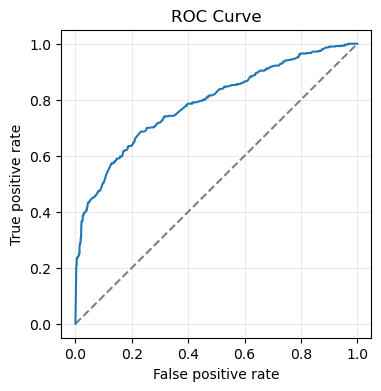

In [82]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
plt.figure(figsize=(4, 4))
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba[:,1])
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.plot(fpr, tpr, label='ROC')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title('ROC Curve')
plt.grid(True, linewidth = 0.5, alpha = 0.4)
plt.show()

In [80]:
y_train.value_counts(normalize=True)
#Guessing the accuracy of predicting the prob of an ipad being sold

sold
0    0.537634
1    0.462366
Name: proportion, dtype: float64

In [81]:
#the more bow shaped it is the better you are from the baseline here 0.5 

In [83]:
#y_pred2 = logit.predict_proba(X_train.loc[:,['startprice', 'condition_new', 'condition_refurbished', 'condition_used']], y_train)
#y_pred2[:10,1] > 0.5
######## REDO ########

In [84]:
##Full Model

In [85]:
logit = LogisticRegression(max_iter=10000,random_state=1031)
logit.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1031
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [86]:
y_pred = logit.predict(X_train)
y_pred_proba = logit.predict_proba(X_train)
y_pred_test = logit.predict(X_test)
y_pred_proba_test = logit.predict_proba(X_test)

In [87]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train, y_pred)

array([[589, 111],
       [168, 434]])

In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
sensitivity_or_recall = recall_score(y_train, y_pred)
auc = roc_auc_score(y_train, y_pred_proba[:,1])

pd.Series(data = [accuracy, precision, sensitivity_or_recall, auc],
          index=['Accuracy','Precision', 'Sensitivity or Recall', 'Area Under the Curve'])

Accuracy                 0.785714
Precision                0.796330
Sensitivity or Recall    0.720930
Area Under the Curve     0.857488
dtype: float64

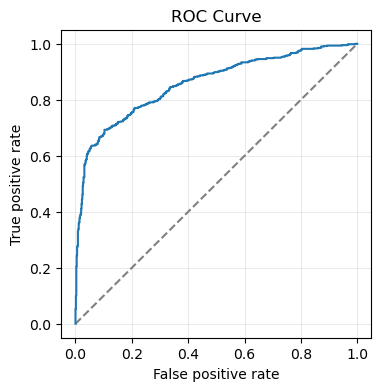

In [91]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
plt.figure(figsize=(4, 4))
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba[:,1])
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.plot(fpr, tpr, label='ROC')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title('ROC Curve')
plt.grid(True, linewidth = 0.5, alpha = 0.4)
plt.show()